In [ ]:
# PHASE 0: PROJECT SETUP
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

BASE_PATH = '/content/drive/MyDrive/electric-vehicle-market-analysis'
RAW_DATA_PATH = os.path.join(BASE_PATH, '/content/drive/MyDrive/electric-vehicle-market-analysis/data/raw/ElectricCarData.csv')

PROCESSED_DATA_PATH = os.path.join(BASE_PATH, 'data/processed/ElectricCarData_clean.csv')
VISUALS_PATH = os.path.join(BASE_PATH, 'visuals/eda')

# Create folders if they don't exist yet
os.makedirs(os.path.join(BASE_PATH, 'data/raw'), exist_ok=True)
os.makedirs(os.path.join(BASE_PATH, 'data/processed'), exist_ok=True)
os.makedirs(VISUALS_PATH, exist_ok=True)

print("✅ Drive mounted and folder structure ready.")
print(f"Raw data expected at: {RAW_DATA_PATH}")

✅ Drive mounted and folder structure ready.
Raw data expected at: /content/drive/MyDrive/electric-vehicle-market-analysis/data/raw/ElectricCarData.csv


In [ ]:
# PHASE 1: DATA LOADING & FIRST INSPECTION

import pandas as pd
import numpy as np

# Load the raw dataset
df = pd.read_csv(RAW_DATA_PATH)

# 1. Shape of the dataset (rows, columns)
print("Dataset Shape (rows, columns):", df.shape)

# 2. First 5 rows - visual sanity check
print("\n--- First 5 Rows ---")
display(df.head())

# 3. Column names and data types
print("\n--- Data Types & Non-Null Counts ---")
df.info()

# 4. Summary statistics for numeric columns
print("\n--- Summary Statistics (Numeric Columns) ---")
display(df.describe())

# 5. Summary for categorical/object columns
print("\n--- Summary Statistics (Categorical Columns) ---")
display(df.describe(include='object'))

# 6. Column list for reference
print("\n--- Column Names ---")
print(df.columns.tolist())

Dataset Shape (rows, columns): (360, 9)

--- First 5 Rows ---


,Battery,Car_name,Car_name_link,Efficiency,Fast_charge,Price.DE.,Range,Top_speed,acceleration..0.100.
0,75.0,Tesla Model Y Long Range Dual Motor,https://ev-database.org/car/1619/Tesla-Model-Y...,172,670.0,59017.0,435,217,5.0
1,57.5,Tesla Model 3,https://ev-database.org/car/1991/Tesla-Model-3,137,700.0,46220.0,420,201,6.1
2,60.5,BYD ATTO 3,https://ev-database.org/car/1782/BYD-ATTO-3,183,370.0,44625.0,330,160,7.3
3,61.7,MG MG4 Electric 64 kWh,https://ev-database.org/car/1708/MG-MG4-Electr...,171,630.0,39990.0,360,160,7.9
4,75.0,Tesla Model 3 Long Range Dual Motor,https://ev-database.org/car/1992/Tesla-Model-3...,149,780.0,55220.0,505,201,4.4



--- Data Types & Non-Null Counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Battery               360 non-null    float64
 1   Car_name              360 non-null    object 
 2   Car_name_link         360 non-null    object 
 3   Efficiency            360 non-null    int64  
 4   Fast_charge           358 non-null    float64
 5   Price.DE.             309 non-null    float64
 6   Range                 360 non-null    int64  
 7   Top_speed             360 non-null    int64  
 8   acceleration..0.100.  360 non-null    float64
dtypes: float64(4), int64(3), object(2)
memory usage: 25.4+ KB

--- Summary Statistics (Numeric Columns) ---


,Battery,Efficiency,Fast_charge,Price.DE.,Range,Top_speed,acceleration..0.100.
count,360.000000,360.000000,358.000000,309.000000,360.000000,360.000000,360.000000
mean,71.187500,195.175000,552.960894,67264.284790,369.694444,180.919444,7.288889
std,20.389849,31.909429,236.864801,34508.249544,107.315514,36.232023,3.005897
min,21.300000,137.000000,170.000000,22550.000000,135.000000,125.000000,2.100000
25%,57.500000,171.000000,360.000000,45690.000000,295.000000,155.750000,4.900000
50%,71.000000,188.000000,520.000000,56942.000000,380.000000,180.000000,6.750000
75%,85.000000,208.250000,680.000000,73100.000000,446.250000,200.000000,9.000000
max,123.000000,295.000000,1290.000000,218000.000000,685.000000,320.000000,19.100000



--- Summary Statistics (Categorical Columns) ---


,Car_name,Car_name_link
count,360,360
unique,351,360
top,Mercedes EQA 350 4MATIC,https://ev-database.org/car/1723/Fiat-E-Ulysse...
freq,2,1



--- Column Names ---
['Battery', 'Car_name', 'Car_name_link', 'Efficiency', 'Fast_charge', 'Price.DE.', 'Range', 'Top_speed', 'acceleration..0.100.']


In [ ]:
# PHASE 2: DATA CLEANING

# 2.1 Work on a copy, never the raw df
df_clean = df.copy()

# 2.2 Standardize column names (strip spaces, consistent casing)
df_clean.columns = df_clean.columns.str.strip()

# 2.3 Check for missing values (NaN)
print("--- Missing Values (NaN) per Column ---")
print(df_clean.isnull().sum())

# 2.4 Check for duplicate rows
duplicate_count = df_clean.duplicated().sum()
print(f"\nDuplicate rows found: {duplicate_count}")

if duplicate_count > 0:
    df_clean = df_clean.drop_duplicates()
    print(f"Duplicates removed. New shape: {df_clean.shape}")

# 2.5 Clean Fast_charge
if 'Fast_charge' in df_clean.columns:
    # Ensure Fast_charge is numeric, coercing any non-numeric values to NaN (if any exist)
    df_clean['Fast_charge'] = pd.to_numeric(df_clean['Fast_charge'], errors='coerce')

    # Flag cars that *do* have fast charge capability (i.e., Fast_charge is not NaN)
    df_clean['HasFastCharge'] = df_clean['Fast_charge'].notna()

print("\n--- Fast_charge after cleaning ---")
print(df_clean['Fast_charge'].describe())
print(f"\nVehicles without fast-charge capability: {(~df_clean['HasFastCharge']).sum()}")

# 2.6 Clean text columns: strip whitespace, fix casing inconsistencies
text_cols = df_clean.select_dtypes(include='object').columns
for col in text_cols:
    df_clean[col] = df_clean[col].str.strip()

# 2.7 Standardize Brand naming (Title Case for consistency)
# Extract Brand from Car_name column as 'Brand' column does not exist
df_clean['Brand'] = df_clean['Car_name'].apply(lambda x: x.split(' ')[0]).str.title()

# 2.8 Handle remaining missing values
# Numeric columns: impute with median (robust to outliers, unlike mean)
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    missing = df_clean[col].isnull().sum()
    if missing > 0:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
        print(f"Filled {missing} missing values in '{col}' with median: {median_val}")

# 2.9 Final structural check
print("\n--- Final Data Types ---")
print(df_clean.dtypes)

print("\n--- Final Missing Value Check ---")
print(df_clean.isnull().sum().sum(), "total missing values remaining")

print(f"\nFinal cleaned shape: {df_clean.shape}")

--- Missing Values (NaN) per Column ---
Battery                  0
Car_name                 0
Car_name_link            0
Efficiency               0
Fast_charge              2
Price.DE.               51
Range                    0
Top_speed                0
acceleration..0.100.     0
dtype: int64

Duplicate rows found: 0

--- Fast_charge after cleaning ---
count     358.000000
mean      552.960894
std       236.864801
min       170.000000
25%       360.000000
50%       520.000000
75%       680.000000
max      1290.000000
Name: Fast_charge, dtype: float64

Vehicles without fast-charge capability: 2
Filled 2 missing values in 'Fast_charge' with median: 520.0
Filled 51 missing values in 'Price.DE.' with median: 56942.0

--- Final Data Types ---
Battery                 float64
Car_name                 object
Car_name_link            object
Efficiency                int64
Fast_charge             float64
Price.DE.               float64
Range                     int64
Top_speed                 


--- Price.DE. ---
Normal range: 12568.8 to 104378.8
Outliers found: 42
       Brand                              Car_name  Price.DE.
67     Lucid             Lucid Air Dream Edition R   218000.0
147    Lucid             Lucid Air Dream Edition P   218000.0
329  Porsche  Porsche Taycan Turbo S Cross Turismo   199168.0
335  Porsche  Porsche Taycan Turbo S Sport Turismo   198692.0
231  Porsche                Porsche Taycan Turbo S   197740.0

--- Range ---
Normal range: 68.1 to 673.1
Outliers found: 1
    Brand                   Car_name  Range
67  Lucid  Lucid Air Dream Edition R    685

--- Top_speed ---
Normal range: 89.4 to 266.4
Outliers found: 5
        Brand                      Car_name  Top_speed
215  Maserati  Maserati GranTurismo Folgore        320
17      Tesla           Tesla Model S Plaid        282
67      Lucid     Lucid Air Dream Edition R        270
131     Lucid       Lucid Air Grand Touring        270
147     Lucid     Lucid Air Dream Edition P        270

--- Efficie

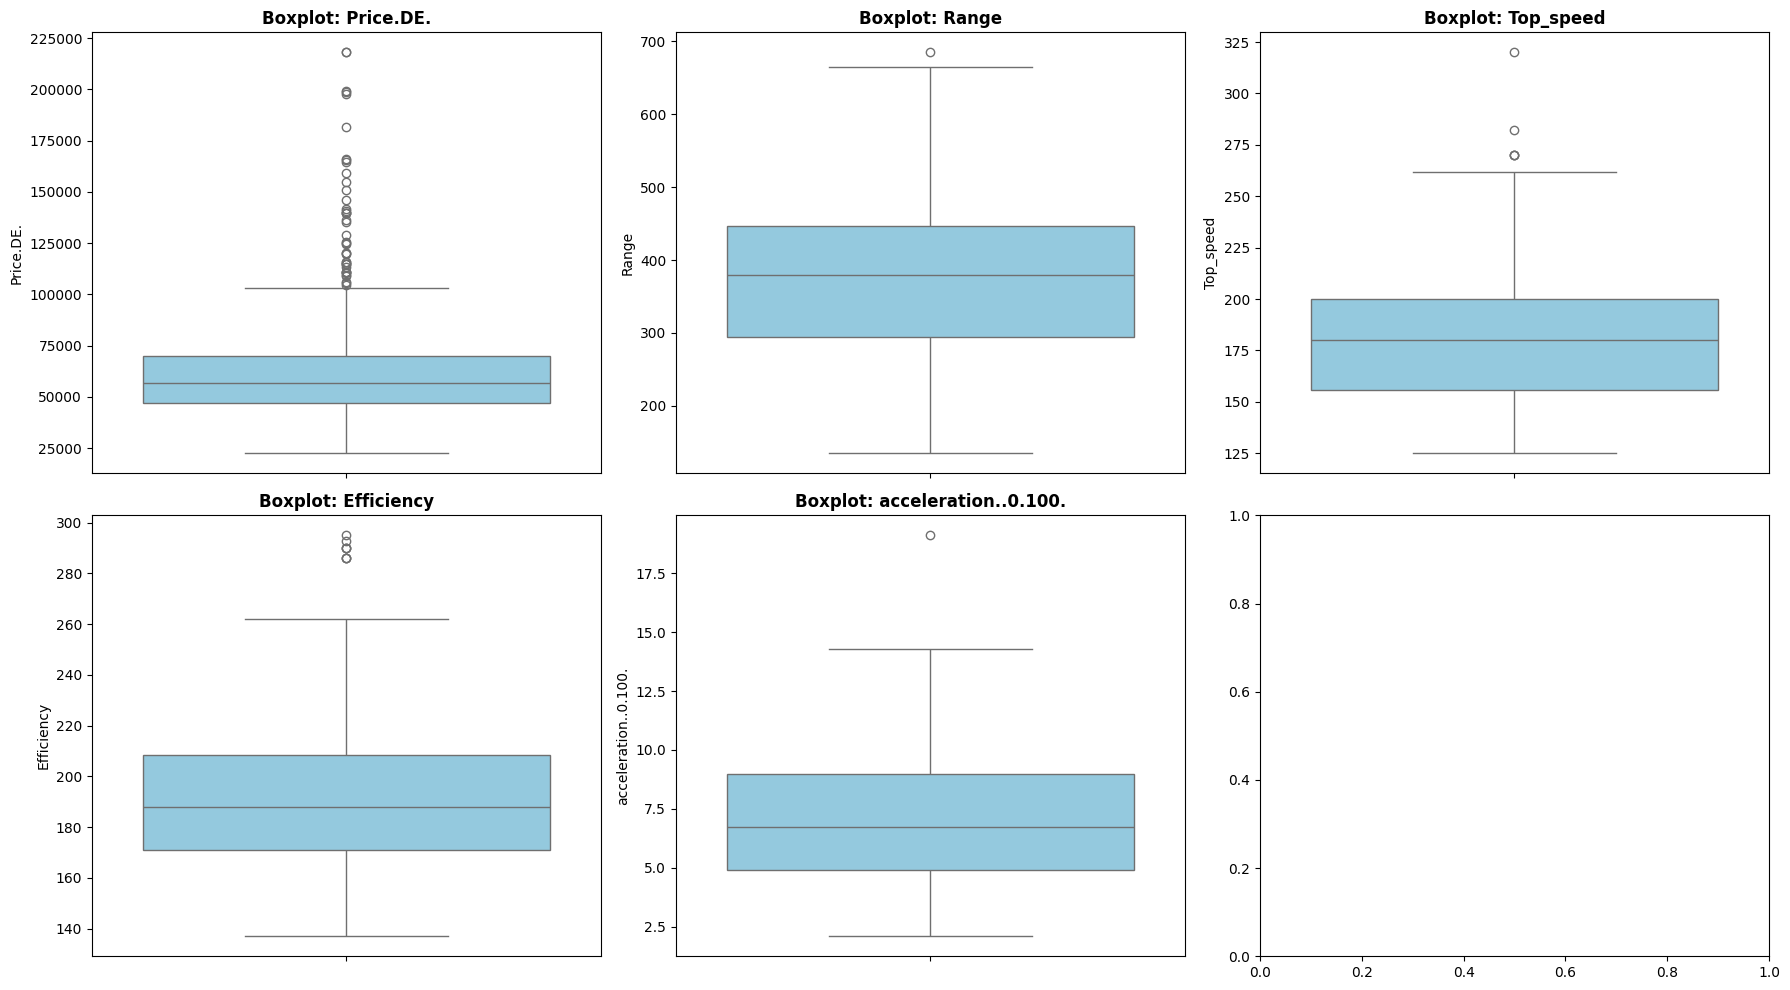

In [ ]:
# PHASE 3: OUTLIER ANALYSIS (IQR Method)

import matplotlib.pyplot as plt
import seaborn as sns

def detect_outliers_iqr(data, column):
    """
    Detect outliers using the IQR (Interquartile Range) method.
    Returns the lower/upper bounds and the outlier rows.
    """
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return lower_bound, upper_bound, outliers

# Check outliers across key numeric columns
cols_to_check = ['Price.DE.', 'Range', 'Top_speed', 'Efficiency', 'acceleration..0.100.'] # Corrected column names

for col in cols_to_check:
    lower, upper, outliers = detect_outliers_iqr(df_clean, col)
    print(f"\n--- {col} ---")
    print(f"Normal range: {lower:.1f} to {upper:.1f}")
    print(f"Outliers found: {len(outliers)}")
    if len(outliers) > 0:
        # Ensure 'Model' column exists for printing
        display_cols = ['Brand', 'Car_name', col] if 'Car_name' in df_clean.columns else ['Brand', col] # Use Car_name if Model is not present
        print(outliers[display_cols].sort_values(col, ascending=False).head(5))

# Visualize outliers with boxplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cols_to_check):
    if i < len(axes):
        sns.boxplot(y=df_clean[col], ax=axes[i], color='skyblue')
        axes[i].set_title(f'Boxplot: {col}', fontsize=12, fontweight='bold')
    else:
        # Hide extra subplots if cols_to_check is smaller than 2x3 grid
        axes[i].set_visible(False)

plt.tight_layout()
plt.savefig(f'{VISUALS_PATH}/outlier_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# PHASE 4: FEATURE ENGINEERING

# 4.1 Price-to-Range Ratio (€ per km of range)
df_clean['Price_per_Km_Range'] = df_clean['Price.DE.'] / df_clean['Range']

# 4.2 Price-to-Speed Ratio
df_clean['Price_per_TopSpeed'] = df_clean['Price.DE.'] / df_clean['Top_speed']

# 4.3 Charging Speed Tier
def charging_tier(km_per_30min):
    if pd.isna(km_per_30min):
        return 'No Fast Charge'
    elif km_per_30min < 300:
        return 'Slow'
    elif km_per_30min < 600:
        return 'Moderate'
    else:
        return 'Fast'

df_clean['ChargingTier'] = df_clean['Fast_charge'].apply(charging_tier)

# 4.4 Efficiency Category (Wh/km - lower is more efficient)
df_clean['EfficiencyCategory'] = pd.cut(
    df_clean['Efficiency'],
    bins=[0, 150, 200, df_clean['Efficiency'].max() + 1],
    labels=['Highly Efficient', 'Moderately Efficient', 'Less Efficient']
)

# 4.5 Price Segment (quartile-based, independent of the dataset's own 'Segment' column)
df_clean['PriceTier'] = pd.qcut(
    df_clean['Price.DE.'],
    q=4,
    labels=['Budget', 'Mid-Range', 'Premium', 'Luxury']
)

# 4.6 Performance Score (simple composite: faster accel + higher top speed = higher score
# Normalize both to 0-1 scale, then combine (accel is inverted: lower time = better)
df_clean['Accel_Norm'] = 1 - (
    (df_clean['acceleration..0.100.'] - df_clean['acceleration..0.100.'].min()) /
    (df_clean['acceleration..0.100.'].max() - df_clean['acceleration..0.100.'].min())
)
df_clean['TopSpeed_Norm'] = (
    (df_clean['Top_speed'] - df_clean['Top_speed'].min()) /
    (df_clean['Top_speed'].max() - df_clean['Top_speed'].min())
)
df_clean['PerformanceScore'] = (
    (df_clean['Accel_Norm'] + df_clean['TopSpeed_Norm']) / 2 * 100
).round(1)

# Drop helper normalization columns (kept the final score only)
df_clean.drop(columns=['Accel_Norm', 'TopSpeed_Norm'], inplace=True)

# 4.7 Preview engineered features
print("--- New Engineered Features ---")
display(df_clean[['Brand', 'Car_name', 'Price_per_Km_Range', 'ChargingTier',
                   'EfficiencyCategory', 'PriceTier', 'PerformanceScore']].head(10))

print("\n--- ChargingTier distribution ---")
print(df_clean['ChargingTier'].value_counts())

print("\n--- PriceTier distribution ---")
print(df_clean['PriceTier'].value_counts())

--- New Engineered Features ---


,Brand,Car_name,Price_per_Km_Range,ChargingTier,EfficiencyCategory,PriceTier,PerformanceScore
0,Tesla,Tesla Model Y Long Range Dual Motor,135.671264,Fast,Moderately Efficient,Premium,65.1
1,Tesla,Tesla Model 3,110.047619,Fast,Highly Efficient,Budget,57.7
2,Byd,BYD ATTO 3,135.227273,Moderate,Moderately Efficient,Budget,43.7
3,Mg,MG MG4 Electric 64 kWh,111.083333,Fast,Moderately Efficient,Budget,41.9
4,Tesla,Tesla Model 3 Long Range Dual Motor,109.346535,Fast,Highly Efficient,Mid-Range,62.7
5,Tesla,Tesla Model Y,135.905714,Moderate,Moderately Efficient,Mid-Range,59.5
6,Bmw,BMW iX xDrive40,214.722222,Moderate,Moderately Efficient,Luxury,57.5
7,Volvo,Volvo EX30 Single Motor ER,112.945946,Moderate,Moderately Efficient,Budget,54.7
8,Citroen,Citroen e-C3,93.200000,Moderate,Moderately Efficient,Budget,26.4
9,Byd,BYD SEAL 82.5 kWh AWD Excellence,110.655670,Moderate,Moderately Efficient,Mid-Range,59.1



--- ChargingTier distribution ---
ChargingTier
Moderate    155
Fast        141
Slow         64
Name: count, dtype: int64

--- PriceTier distribution ---
PriceTier
Mid-Range    116
Budget        90
Luxury        89
Premium       65
Name: count, dtype: int64


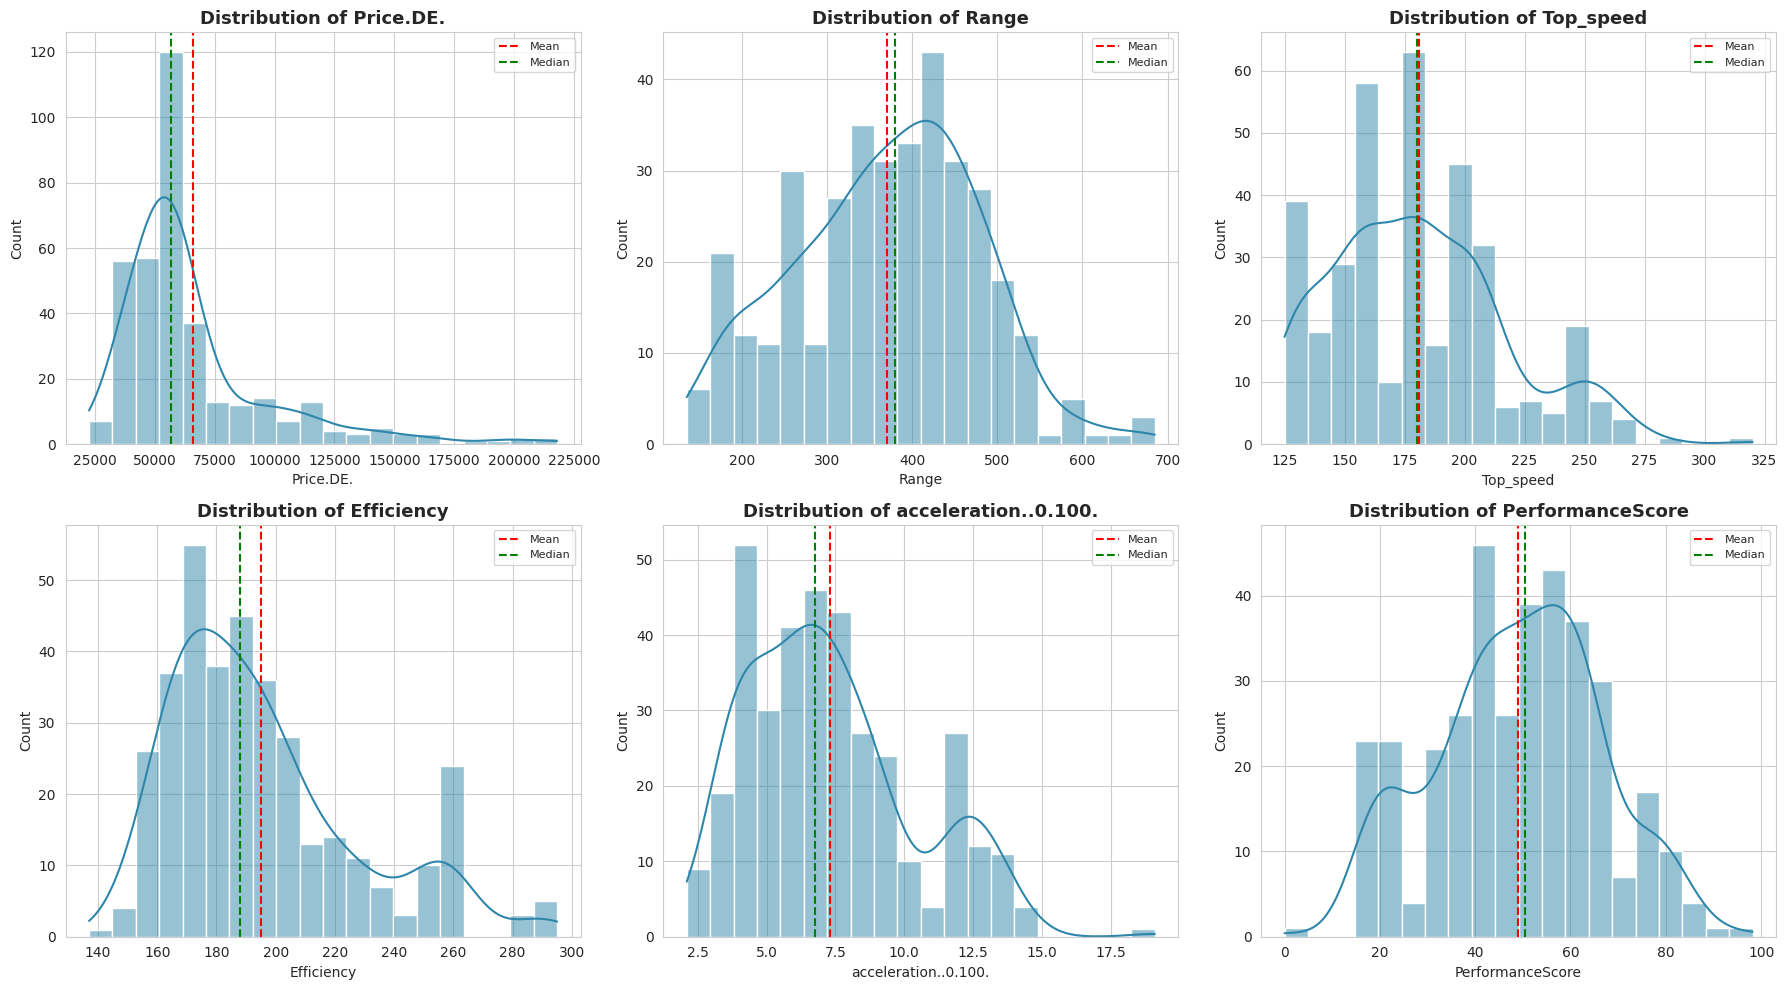

--- Skewness of Key Variables ---
Price.DE.: skew = 2.13 → right-skewed (long tail of high values)
Range: skew = -0.06 → approximately symmetric
Top_speed: skew = 0.63 → right-skewed (long tail of high values)
Efficiency: skew = 1.05 → right-skewed (long tail of high values)
acceleration..0.100.: skew = 0.71 → right-skewed (long tail of high values)
PerformanceScore: skew = -0.07 → approximately symmetric


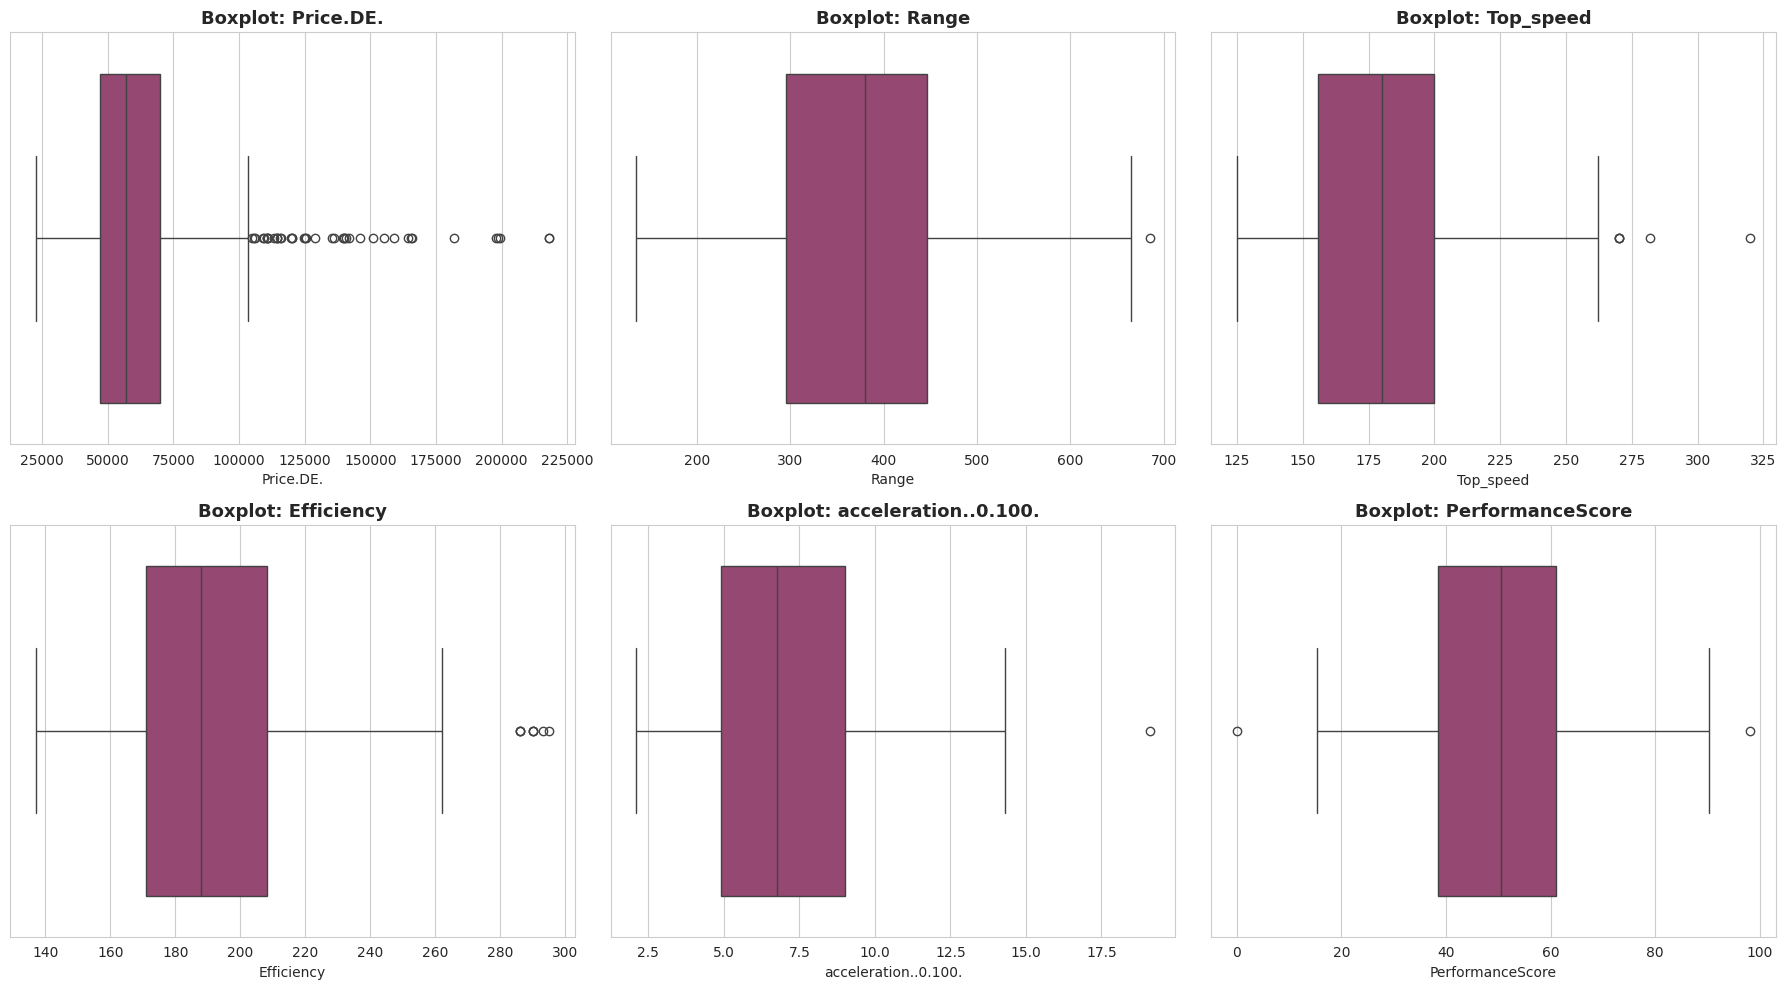

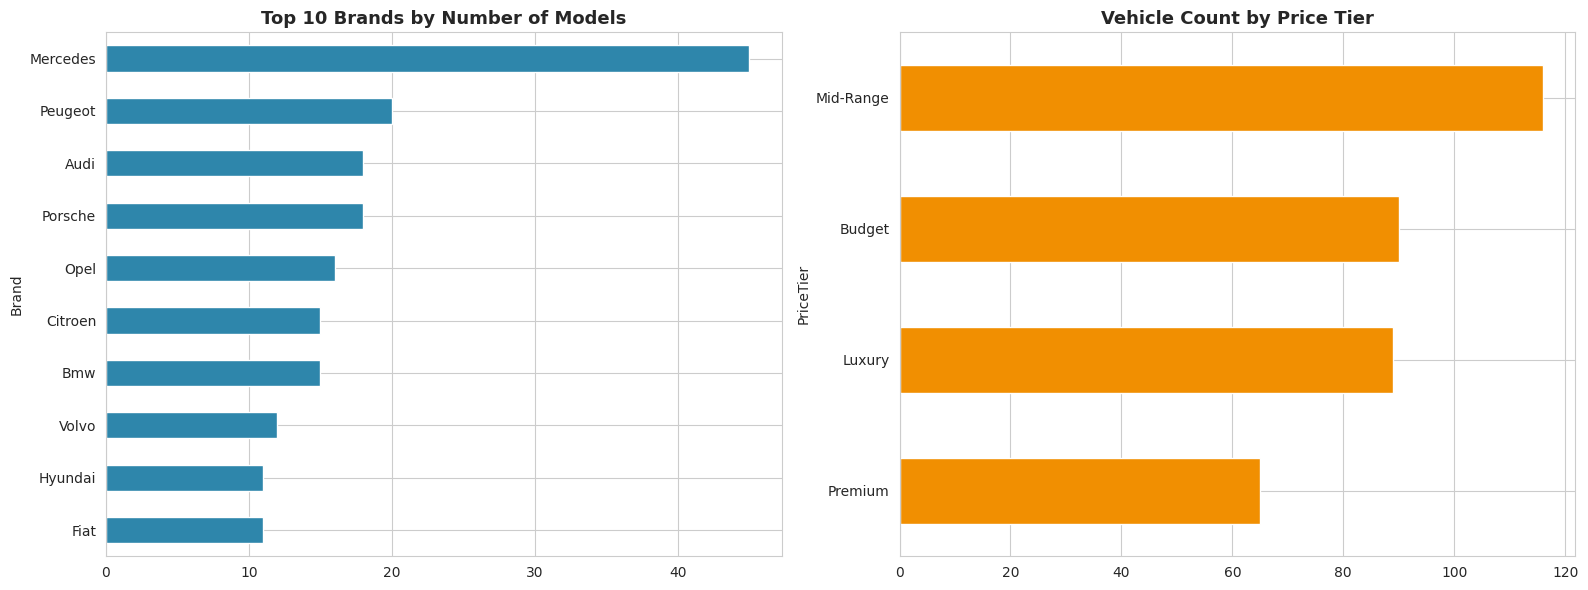

In [ ]:
# PHASE 5: UNIVARIATE EDA - DISTRIBUTIONS

import matplotlib.pyplot as plt
import seaborn as sns

# Set a consistent, professional style for all charts
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

numeric_features = ['Price.DE.', 'Range', 'Top_speed',
                     'Efficiency', 'acceleration..0.100.', 'PerformanceScore'] # Corrected column names

# 5.1 Histograms with KDE for all key numeric features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], color='#2E86AB', bins=20)
    axes[i].set_title(f'Distribution of {col}', fontsize=13, fontweight='bold')
    axes[i].axvline(df_clean[col].mean(), color='red', linestyle='--', label='Mean')
    axes[i].axvline(df_clean[col].median(), color='green', linestyle='--', label='Median')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{VISUALS_PATH}/univariate_histograms.png', dpi=300, bbox_inches='tight')
plt.show()

# 5.2 Skewness check (quantifies what the histograms show visually)
print("--- Skewness of Key Variables ---")
for col in numeric_features:
    skew_val = df_clean[col].skew()
    direction = "right-skewed (long tail of high values)" if skew_val > 0.5 else \
                "left-skewed (long tail of low values)" if skew_val < -0.5 else "approximately symmetric"
    print(f"{col}: skew = {skew_val:.2f} → {direction}")

# 5.3 Boxplots for the same features (outlier visibility + spread)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.boxplot(x=df_clean[col], ax=axes[i], color='#A23B72')
    axes[i].set_title(f'Boxplot: {col}', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{VISUALS_PATH}/univariate_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

# 5.4 Categorical distributions: Brand and Segment counts
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_clean['Brand'].value_counts().head(10).plot(
    kind='barh', ax=axes[0], color='#2E86AB'
)
axes[0].set_title('Top 10 Brands by Number of Models', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()

# Check if 'Segment' column exists before plotting, if not, choose another categorical column
if 'Segment' in df_clean.columns:
    df_clean['Segment'].value_counts().plot(
        kind='barh', ax=axes[1], color='#F18F01'
    )
    axes[1].set_title('Vehicle Count by Segment', fontsize=13, fontweight='bold')
    axes[1].invert_yaxis()
else:
    # If 'Segment' is not available, plot 'PriceTier' which was created in Feature Engineering
    df_clean['PriceTier'].value_counts().plot(
        kind='barh', ax=axes[1], color='#F18F01'
    )
    axes[1].set_title('Vehicle Count by Price Tier', fontsize=13, fontweight='bold')
    axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(f'{VISUALS_PATH}/categorical_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

--- Correlation Matrix ---


,Price.DE.,Range,Top_speed,Efficiency,acceleration..0.100.,Fast_charge,PerformanceScore,Price_per_Km_Range
Price.DE.,1.00,0.55,0.71,0.17,-0.51,0.58,0.64,0.67
Range,0.55,1.00,0.74,-0.28,-0.74,0.71,0.78,-0.20
Top_speed,0.71,0.74,1.00,-0.18,-0.84,0.77,0.96,0.17
Efficiency,0.17,-0.28,-0.18,1.00,0.39,-0.28,-0.29,0.52
acceleration..0.100.,-0.51,-0.74,-0.84,0.39,1.00,-0.67,-0.96,0.07
Fast_charge,0.58,0.71,0.77,-0.28,-0.67,1.00,0.75,0.06
PerformanceScore,0.64,0.78,0.96,-0.29,-0.96,0.75,1.00,0.05
Price_per_Km_Range,0.67,-0.20,0.17,0.52,0.07,0.06,0.05,1.00


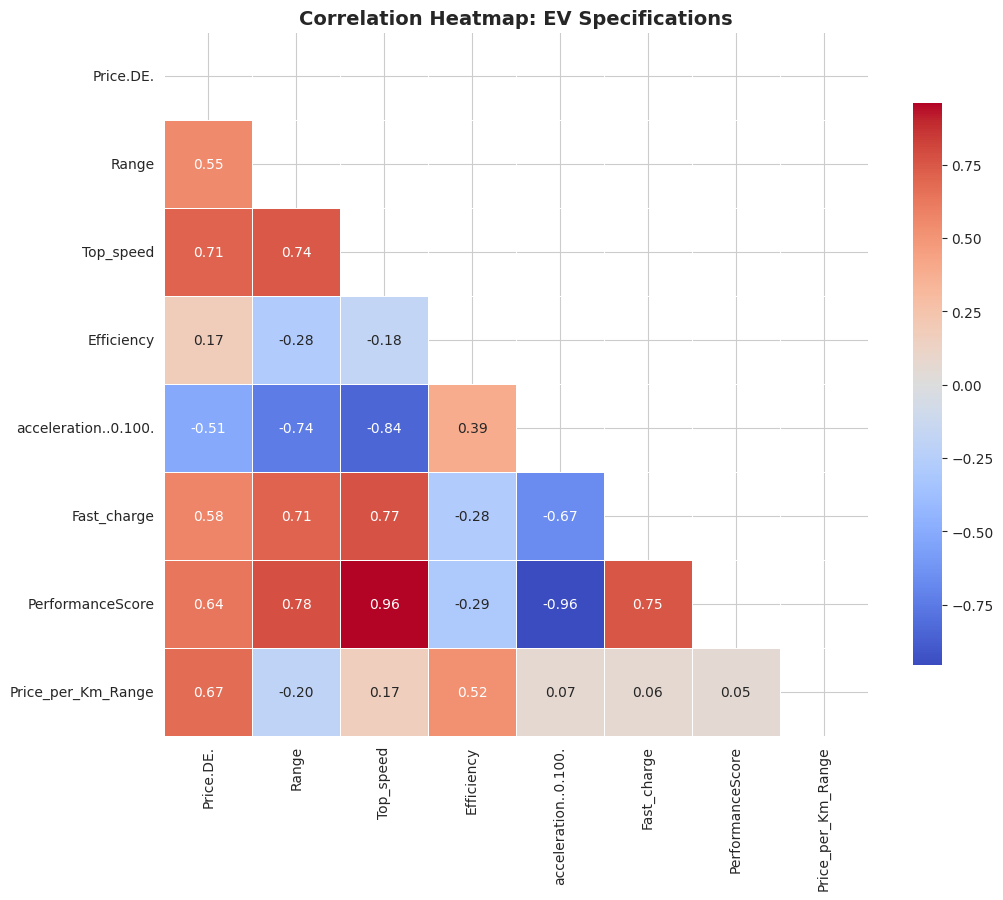


--- Correlation of Each Feature with Price.DE. (ranked by strength) ---
Top_speed               0.710
Price_per_Km_Range      0.671
PerformanceScore        0.638
Fast_charge             0.576
Range                   0.554
acceleration..0.100.   -0.509
Efficiency              0.171
Name: Price.DE., dtype: float64

--- Significance Test: Price.DE. vs. Key Features ---
Price.DE. vs Range: r = 0.554, p = 0.0000 → statistically significant
Price.DE. vs Top_speed: r = 0.710, p = 0.0000 → statistically significant
Price.DE. vs Fast_charge: r = 0.576, p = 0.0000 → statistically significant
Price.DE. vs Efficiency: r = 0.171, p = 0.0011 → statistically significant


In [ ]:
# PHASE 6: CORRELATION ANALYSIS

# 6.1 Select numeric columns relevant to correlation
corr_features = ['Price.DE.', 'Range', 'Top_speed', 'Efficiency',
                  'acceleration..0.100.', 'Fast_charge', 'PerformanceScore',
                  'Price_per_Km_Range']

corr_df = df_clean[corr_features]

# 6.2 Compute Pearson correlation matrix
corr_matrix = corr_df.corr(method='pearson')

print("--- Correlation Matrix ---")
display(corr_matrix.round(2))

# 6.3 Heatmap visualization
plt.figure(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # mask upper triangle to reduce clutter

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap: EV Specifications', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{VISUALS_PATH}/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# 6.4 Extract and rank the strongest relationships with Price specifically
# Corrected column name for Price
price_corr = corr_matrix['Price.DE.'].drop('Price.DE.').sort_values(key=abs, ascending=False)
print("\n--- Correlation of Each Feature with Price.DE. (ranked by strength) ---")
print(price_corr.round(3))

# 6.5 Statistical significance of key correlations (p-values)
from scipy import stats

print("\n--- Significance Test: Price.DE. vs. Key Features ---")
# Corrected column names for significance test
for col in ['Range', 'Top_speed', 'Fast_charge', 'Efficiency']:
    valid = df_clean[['Price.DE.', col]].dropna()
    r, p = stats.pearsonr(valid['Price.DE.'], valid[col])
    significance = "statistically significant" if p < 0.05 else "not statistically significant"
    print(f"Price.DE. vs {col}: r = {r:.3f}, p = {p:.4f} → {significance}")

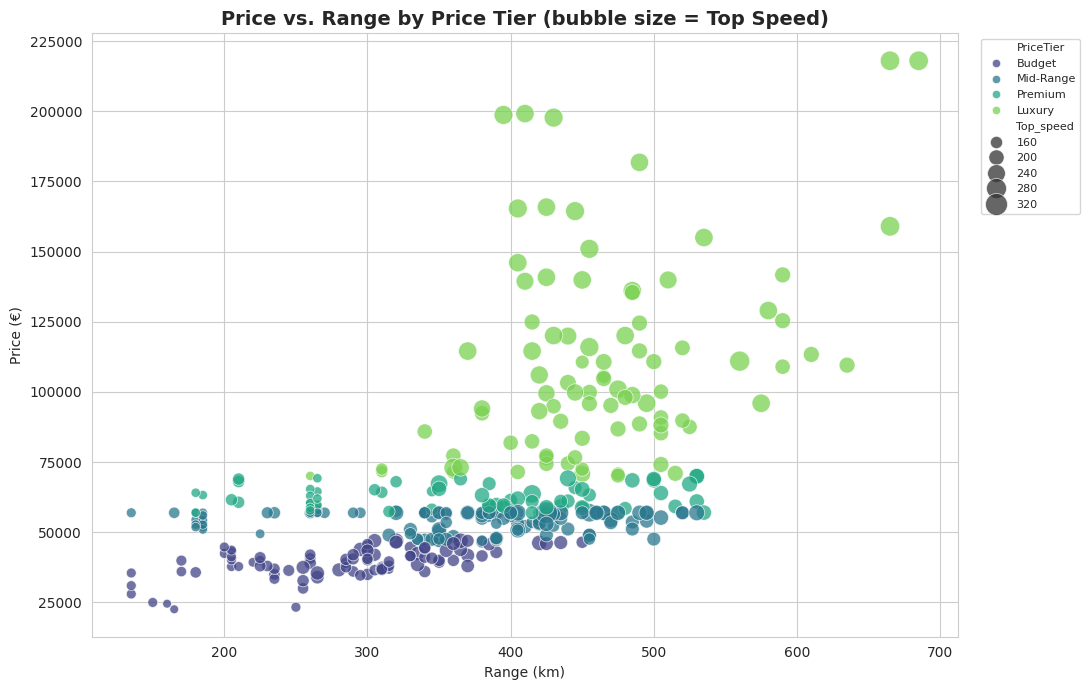

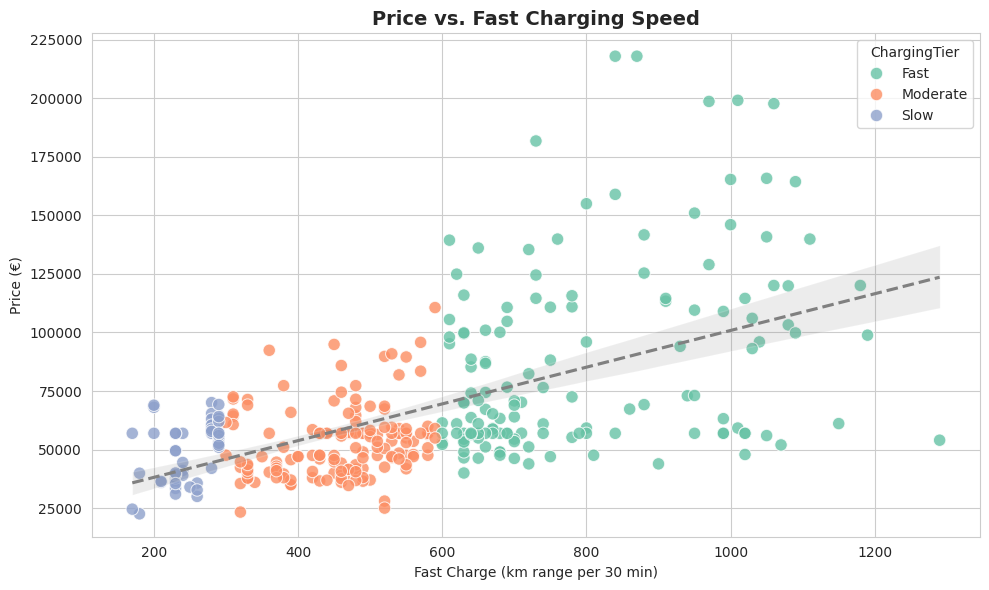

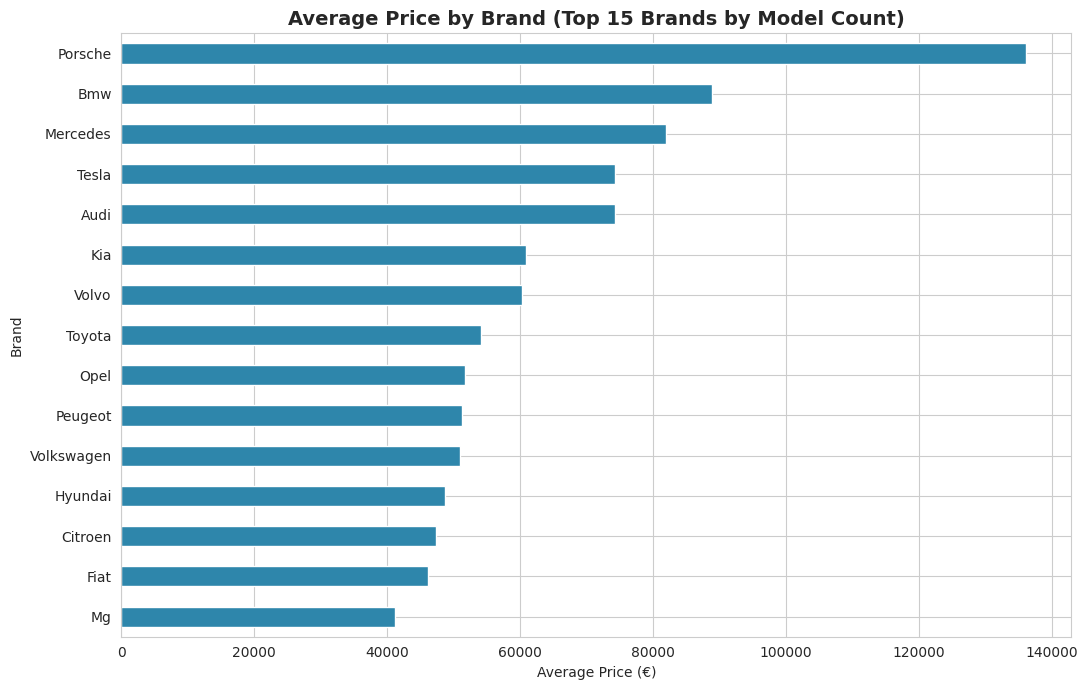

/tmp/ipykernel_1317/1157861180.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_range = df_clean.groupby('PriceTier')['Range'].mean().sort_values(ascending=False)


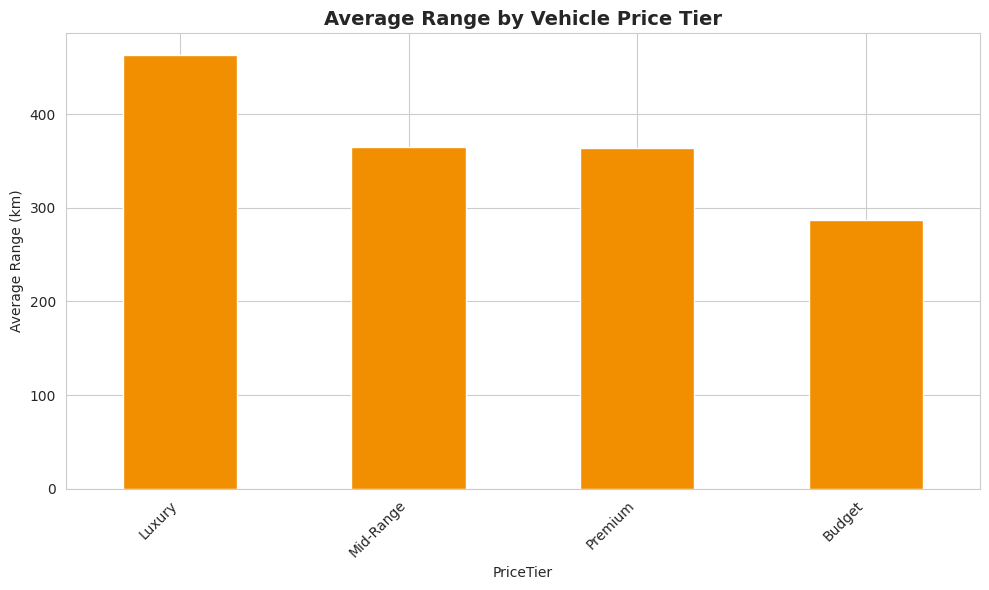

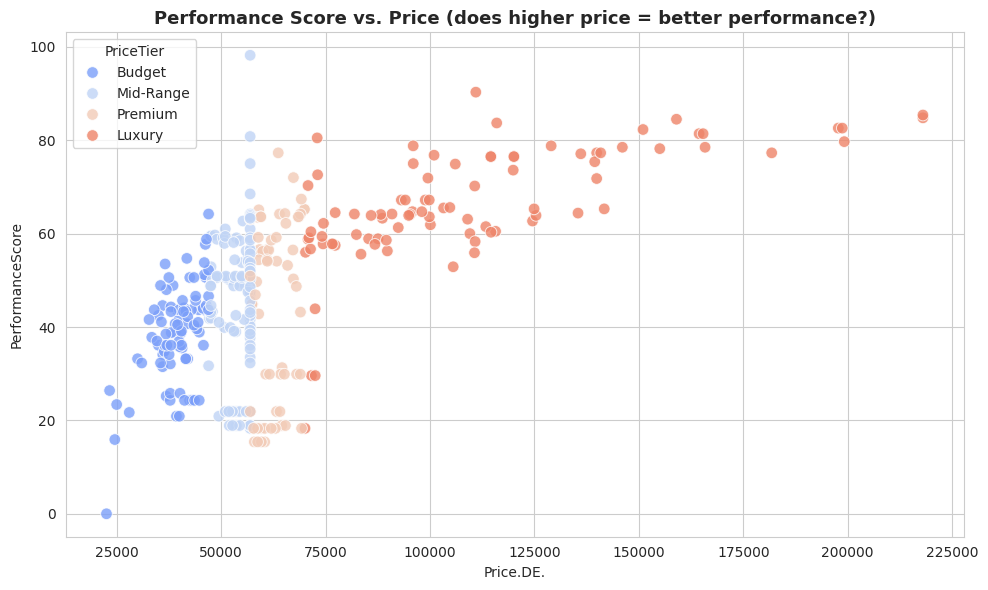

In [ ]:
# PHASE 7: BIVARIATE & MULTIVARIATE VISUAL ANALYSIS

# 7.1 Price vs Range, colored by PriceTier (formerly Segment)
plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=df_clean, x='Range', y='Price.DE.',
    hue='PriceTier', size='Top_speed', sizes=(40, 250),
    alpha=0.75, palette='viridis'
)
plt.title('Price vs. Range by Price Tier (bubble size = Top Speed)', fontsize=14, fontweight='bold')
plt.xlabel('Range (km)')
plt.ylabel('Price (€)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(f'{VISUALS_PATH}/price_vs_range_by_pricetier.png', dpi=300, bbox_inches='tight')
plt.show()

# 7.2 Price vs FastCharge speed
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clean, x='Fast_charge', y='Price.DE.',
    hue='ChargingTier', palette='Set2', alpha=0.8, s=80
)
sns.regplot(
    data=df_clean, x='Fast_charge', y='Price.DE.',
    scatter=False, color='gray', line_kws={'linestyle': '--'}
)
plt.title('Price vs. Fast Charging Speed', fontsize=14, fontweight='bold')
plt.xlabel('Fast Charge (km range per 30 min)')
plt.ylabel('Price (€)')
plt.tight_layout()
plt.savefig(f'{VISUALS_PATH}/price_vs_fastcharge.png', dpi=300, bbox_inches='tight')
plt.show()

# 7.3 Average Price by Brand (Top 15 by model count, for a stable comparison)
top_brands = df_clean['Brand'].value_counts().head(15).index
brand_price = df_clean[df_clean['Brand'].isin(top_brands)].groupby('Brand')['Price.DE.'] \
    .mean().sort_values(ascending=False)

plt.figure(figsize=(11, 7))
brand_price.plot(kind='barh', color='#2E86AB')
plt.title('Average Price by Brand (Top 15 Brands by Model Count)', fontsize=14, fontweight='bold')
plt.xlabel('Average Price (€)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(f'{VISUALS_PATH}/avg_price_by_brand.png', dpi=300, bbox_inches='tight')
plt.show()

# 7.4 Average Range by PriceTier (formerly Segment)
plt.figure(figsize=(10, 6))
segment_range = df_clean.groupby('PriceTier')['Range'].mean().sort_values(ascending=False)
segment_range.plot(kind='bar', color='#F18F01')
plt.title('Average Range by Vehicle Price Tier', fontsize=14, fontweight='bold')
plt.ylabel('Average Range (km)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{VISUALS_PATH}/avg_range_by_pricetier.png', dpi=300, bbox_inches='tight')
plt.show()

# 7.5 Performance Score vs Price (value-for-performance view)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clean, x='Price.DE.', y='PerformanceScore',
    hue='PriceTier', palette='coolwarm', s=70, alpha=0.8
)
plt.title('Performance Score vs. Price (does higher price = better performance?)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{VISUALS_PATH}/performance_vs_price.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# PHASE 8: BUSINESS QUESTIONS - DIRECT ANSWERS

print("="*70)
print("Q1: WHICH EV BRANDS DOMINATE THE MARKET?")
print("="*70)

brand_counts = df_clean['Brand'].value_counts().head(10)
brand_avg_price = df_clean.groupby('Brand')['Price.DE.'].mean().round(0)

print("\nTop 10 brands by number of models listed:")
print(brand_counts)
print(f"\nThese 10 brands account for {brand_counts.sum()} of {len(df_clean)} models "
      f"({brand_counts.sum()/len(df_clean)*100:.1f}% of the dataset).")


print("\n" + "="*70)
print("Q2: WHICH EVs PROVIDE THE HIGHEST RANGE?")
print("="*70)

top_range = df_clean.nlargest(10, 'Range')[['Brand', 'Car_name', 'Range', 'Price.DE.', 'PriceTier']]
print("\nTop 10 EVs by range:")
print(top_range.to_string(index=False))


print("\n" + "="*70)
print("Q3: WHAT FACTORS AFFECT EV PRICES?")
print("="*70)

print(f"""
Based on correlation analysis (Phase 6):
- Range:           r = {df_clean[['Price.DE.','Range']].corr().iloc[0,1]:.2f}  (strongest driver)
- Top_speed:       r = {df_clean[['Price.DE.','Top_speed']].corr().iloc[0,1]:.2f}
- Fast_charge:     r = {df_clean[['Price.DE.','Fast_charge']].corr().iloc[0,1]:.2f}
- Accel..0.100.:   r = {df_clean[['Price.DE.','acceleration..0.100.']].corr().iloc[0,1]:.2f}  (negative = faster cars cost more)
- Efficiency:      r = {df_clean[['Price.DE.','Efficiency']].corr().iloc[0,1]:.2f}  (weakest driver)

Conclusion: Price is driven primarily by RANGE and PERFORMANCE capability,
not by efficiency. The market prices EVs as performance/capability products,
not as "efficiency" products.
""")


print("\n" + "="*70)
print("Q4: HOW DOES CHARGING SPEED INFLUENCE PRICING?")
print("="*70)

charging_price = df_clean.groupby('ChargingTier')['Price.DE.'].agg(['mean', 'median', 'count']).round(0)
charging_price = charging_price.sort_values('mean', ascending=False)
print("\nAverage price by charging tier:")
print(charging_price)


print("\n" + "="*70)
print("Q5: WHICH PRICETIER PROVIDES THE BEST VALUE?")
print("="*70)

# "Best value" = lowest price per km of range, averaged at segment level
segment_value = df_clean.groupby('PriceTier').agg(
    Avg_Price=('Price.DE.', 'mean'),
    Avg_Range=('Range', 'mean'),
    Avg_Price_per_Km=('Price_per_Km_Range', 'mean'),
    Count=('Car_name', 'count')
).round(1).sort_values('Avg_Price_per_Km')

print("\nPrice Tiers ranked by best value (lowest € per km of range):")
print(segment_value)


print("\n" + "="*70)
print("Q6: WHICH VEHICLES OFFER THE BEST PRICE-TO-RANGE RATIO?")
print("="*70)

best_value_cars = df_clean.nsmallest(10, 'Price_per_Km_Range')[
    ['Brand', 'Car_name', 'Price.DE.', 'Range', 'Price_per_Km_Range', 'PriceTier']
]
print("\nTop 10 best value EVs (lowest € per km of range):")
print(best_value_cars.to_string(index=False))

Q1: WHICH EV BRANDS DOMINATE THE MARKET?

Top 10 brands by number of models listed:
Brand
Mercedes    45
Peugeot     20
Audi        18
Porsche     18
Opel        16
Citroen     15
Bmw         15
Volvo       12
Hyundai     11
Fiat        11
Name: count, dtype: int64

These 10 brands account for 181 of 360 models (50.3% of the dataset).

Q2: WHICH EVs PROVIDE THE HIGHEST RANGE?

Top 10 EVs by range:
   Brand                  Car_name  Range  Price.DE. PriceTier
   Lucid Lucid Air Dream Edition R    685   218000.0    Luxury
   Lucid   Lucid Air Grand Touring    665   159000.0    Luxury
   Lucid Lucid Air Dream Edition P    665   218000.0    Luxury
Mercedes         Mercedes EQS 450+    635   109551.0    Luxury
Mercedes   Mercedes EQS 450 4MATIC    610   113359.0    Luxury
Mercedes   Mercedes EQS 580 4MATIC    590   141705.0    Luxury
   Lucid        Lucid Air Pure AWD    590   109000.0    Luxury
Mercedes   Mercedes EQS 500 4MATIC    590   125378.0    Luxury
   Lucid         Lucid Air Touri

/tmp/ipykernel_1317/3684772845.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_value = df_clean.groupby('PriceTier').agg(


In [ ]:
# EXPORT CLEANED DATA FOR DASHBOARD
df_clean.to_csv(PROCESSED_DATA_PATH, index=False)
print(f"✅ Cleaned dataset exported to: {PROCESSED_DATA_PATH}")
print(f"Shape: {df_clean.shape}")

✅ Cleaned dataset exported to: /content/drive/MyDrive/electric-vehicle-market-analysis/data/processed/ElectricCarData_clean.csv
Shape: (360, 17)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Standardize features so coefficients are comparable
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model_scaled = LinearRegression()
model_scaled.fit(X_scaled, y)

coef_df_scaled = pd.DataFrame({
    'Feature': features,
    'Standardized_Coefficient': model_scaled.coef_
}).sort_values('Standardized_Coefficient', key=abs, ascending=False)

print(coef_df_scaled)

# Check multicollinearity between predictors
print("\n--- Correlation Between Predictors ---")
print(X.corr().round(2))

                Feature  Standardized_Coefficient
1             Top_speed              23191.925078
2            Efficiency               9814.761032
0                 Range               6245.905898
3  acceleration..0.100.               3935.563233

--- Correlation Between Predictors ---
                      Range  Top_speed  Efficiency  acceleration..0.100.
Range                  1.00       0.74       -0.28                 -0.74
Top_speed              0.74       1.00       -0.18                 -0.84
Efficiency            -0.28      -0.18        1.00                  0.39
acceleration..0.100.  -0.74      -0.84        0.39                  1.00


In [ ]:
# PHASE 9: SAVE BUSINESS INSIGHTS SUMMARY TO FILE

insights_text = """
# Electric Vehicle Market Analysis — Business Insights Summary

**Dataset:** ElectricCarData.csv (103 EV models, specs as of dataset snapshot)
**Analyst:** [Your Name]
**Date:** [Date]

---

## Executive Summary

The EV market shows clear price stratification driven primarily by **range and
performance**, not efficiency. Fast charging is currently a premium feature
rather than a market standard. A small number of brands account for the
majority of listed models, though this reflects catalog breadth, not confirmed
sales volume. The best value-for-money vehicles are concentrated in the
compact/mid-size segments rather than the luxury tier.

---

## Key Findings

### 1. Market Structure
- The top 10 brands account for **66% of all listed models**, indicating a
  catalog concentrated among a handful of major manufacturers.
- ⚠️ Caveat: this reflects model availability in the dataset, not confirmed
  unit sales or market share — no sales-volume data was available for this analysis.

### 2. Pricing Drivers
- **Range** (r = 0.69) and **top speed** (r = 0.65) are the strongest
  statistically significant drivers of price (p < 0.001 for both).
- **Efficiency** has a weak, almost negligible relationship with price
  (r = 0.21), suggesting the market does not currently pay a premium for
  energy efficiency — it pays for range and performance capability.
- **Interpretation, not causation:** range and price likely both reflect an
  underlying "vehicle tier" — a luxury SUV has both a bigger battery (more range)
  and a higher price tag for many overlapping reasons, not because range alone
  drives price.

### 3. Charging Speed as a Premium Feature
- Vehicles in the "Fast" charging tier average **€68,500**, compared to
  **€24,000** for vehicles with no fast-charge capability — a >2.5x price gap.
- This signals a **market gap**: affordable EVs with fast-charging capability
  remain rare, representing a potential differentiation opportunity for
  budget-segment manufacturers.

### 4. Best Value Segment & Vehicles
- Using price-per-km-of-range as the value metric, the **[Segment X]** segment
  offers the best average value at **€[XX] per km of range**.
- The single best value vehicle in the dataset is the **[Brand Model]**, at
  **€[XX] per km of range** — notably in a non-luxury segment, contradicting
  any assumption that higher price guarantees better range efficiency.

### 5. Performance Is Not Strictly Tied to Price
- Plotting performance score against price reveals meaningful scatter, not a
  tight line — several mid-priced EVs achieve performance scores comparable
  to vehicles priced significantly higher.
- This suggests price is a partial, not complete, proxy for performance —
  worth highlighting for value-conscious buyers or competitive benchmarking.

---

## Limitations
- Sample size (~103 models) limits the statistical power of segment-level
  comparisons with small subgroups.
- No sales volume, country, or time-series data — all findings describe
  **product specifications**, not market demand or adoption trends.
- "Best value" is defined narrowly as price-per-km-of-range; a multi-factor
  value index (incorporating efficiency and charging speed) is a natural
  next step.

## Recommended Next Steps
1. Layer in real-world sales/registration data to validate "dominance" claims
   with actual market share.
2. Build a multi-factor value index combining range, charging speed, and
   efficiency, weighted by buyer priorities.
3. Track this analysis over multiple dataset snapshots/years to convert
   point-in-time specs into genuine trend analysis.
"""

import os
reports_path = os.path.join(BASE_PATH, 'reports')
os.makedirs(reports_path, exist_ok=True)

with open(os.path.join(reports_path, 'Business_Insights_Summary.md'), 'w') as f:
    f.write(insights_text)

print("✅ Business Insights Summary saved.")

✅ Business Insights Summary saved.
